# GSM8K OPSD vs Base comparison

Modular helpers for comparing GSM8K benchmark summaries across the latest OPSD and base model runs. Adjust `RUN_GROUPS`, `TASK`, or `LATEST_PER_CHECKPOINT` below to change the slice.

In [19]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO = Path("/mnt/dlabscratch1/samaier/projects/SDPO-safety")
OUT = REPO / "outputs/pretrain_benchmarks"

# The benchmark task is named gsm8k in these summaries. If you really add a gsm9k
# task later, changing this one value should be enough for the summary-level views.
TASK = "gsm8k"

RUN_GROUPS = {
    "opsd": [
        OUT / "longctx_opsd_stage2_gsm8k_maxnew7680",
        OUT / "longctx_opsd_stage2_gsm8k_maxnew7680_latest2",
    ],
    "base": [
        OUT / "base_think_len32k_gsm8k_math_500",
        OUT / "base_stage12_len8k_gsm8k_math_500",
        OUT / "gsm8k_base_zeroshot_all_h200g4",
    ],
}

METRICS = ["pass@1", "pass@8", "pass@32"]
TOKEN_COLUMNS = [
    "completion_tokens_mean",
    "completion_tokens_median",
    "completion_tokens_p90",
    "completion_tokens_p99",
    "hit_max_new_tokens_rate",
]
LATEST_PER_CHECKPOINT = True

In [20]:
def parse_run_timestamp(path: Path) -> pd.Timestamp:
    """Extract a timestamp like 20260602_120636 from a summary path."""
    match = re.search(r"/(20\d{6}_\d{6})/", path.as_posix())
    if match:
        return pd.to_datetime(match.group(1), format="%Y%m%d_%H%M%S")
    return pd.to_datetime(path.stat().st_mtime, unit="s")


def read_summary(path: Path, group: str, root: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["group"] = group
    df["root"] = root.name
    df["summary_path"] = str(path)
    df["run_time"] = parse_run_timestamp(path)
    return df


def collect_summaries(run_groups: dict[str, list[Path]], task: str = TASK) -> pd.DataFrame:
    frames = []
    for group, roots in run_groups.items():
        for root in roots:
            if not root.exists():
                print(f"Missing root: {root}")
                continue
            for path in root.rglob("summary.csv"):
                try:
                    frames.append(read_summary(path, group, root))
                except Exception as exc:
                    print(f"Skipping {path}: {exc}")

    if not frames:
        return pd.DataFrame()

    df = pd.concat(frames, ignore_index=True)
    df = df[df["task"].astype(str).str.lower().eq(task.lower())].copy()
    for col in [*METRICS, *TOKEN_COLUMNS, "num_examples", "num_samples", "num_fewshot", "max_new_tokens"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.sort_values("run_time").reset_index(drop=True)


def latest_runs(df: pd.DataFrame, per_checkpoint: bool = True) -> pd.DataFrame:
    if df.empty:
        return df
    keys = ["group", "checkpoint"] if per_checkpoint else ["group"]
    return (
        df.sort_values(["run_time", "summary_path"])
          .groupby(keys, as_index=False)
          .tail(1)
          .sort_values(["group", "checkpoint"])
          .reset_index(drop=True)
    )


def find_runs_without_summary(run_groups: dict[str, list[Path]]) -> pd.DataFrame:
    rows = []
    for group, roots in run_groups.items():
        for root in roots:
            if not root.exists():
                continue
            for run_config_path in root.rglob("run_config.json"):
                run_dir = run_config_path.parent
                if (run_dir / "summary.csv").exists():
                    continue

                checkpoint = run_dir.parent.name
                tasks = []
                try:
                    config = json.loads(run_config_path.read_text())
                    tasks = config.get("tasks") or []
                    if isinstance(tasks, str):
                        tasks = [tasks]
                except Exception:
                    pass

                if not tasks:
                    tasks = sorted({p.name.split("__")[-1].split(".")[0] for p in run_dir.glob("*.jsonl")})

                rows.append({
                    "group": group,
                    "checkpoint": checkpoint,
                    "tasks": ", ".join(map(str, tasks)),
                    "root": root.name,
                    "run_time": parse_run_timestamp(run_config_path),
                    "run_dir": str(run_dir),
                })

    if not rows:
        return pd.DataFrame(columns=["group", "checkpoint", "tasks", "root", "run_time", "run_dir"])
    return pd.DataFrame(rows).sort_values("run_time", ascending=False).reset_index(drop=True)


def with_base_deltas(df: pd.DataFrame, baseline_metric: str = "pass@1") -> pd.DataFrame:
    df = df.copy()
    base = df[df["group"].eq("base")]
    if base.empty or baseline_metric not in df.columns:
        return df
    best_base = base.loc[base[baseline_metric].idxmax()]
    for metric in METRICS:
        if metric in df.columns:
            df[f"{metric}_vs_best_base"] = df[metric] - best_base[metric]
    df["best_base_checkpoint"] = best_base["checkpoint"]
    return df


def display_summary(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "group", "checkpoint", "task", "root", "run_time", "num_examples", "num_samples",
        "num_fewshot", "max_new_tokens", *METRICS, *TOKEN_COLUMNS,
        "pass@1_vs_best_base", "pass@8_vs_best_base", "pass@32_vs_best_base",
        "summary_path",
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols].sort_values(["group", "pass@1"], ascending=[True, False]).round(4)

In [21]:
all_gsm = collect_summaries(RUN_GROUPS, task=TASK)
latest_by_group_gsm = with_base_deltas(latest_runs(all_gsm, per_checkpoint=False))
latest_by_checkpoint_gsm = with_base_deltas(latest_runs(all_gsm, per_checkpoint=True))
runs_without_summary = find_runs_without_summary(RUN_GROUPS)
recent_runs_without_summary = runs_without_summary[
    runs_without_summary["run_time"].ge(all_gsm["run_time"].max())
].copy() if not all_gsm.empty else runs_without_summary

print(f"Loaded {len(all_gsm)} {TASK} summary rows from {len(RUN_GROUPS)} groups.")
print("Latest run per group:")
display(display_summary(latest_by_group_gsm))

print("Latest run per checkpoint:")
display(display_summary(latest_by_checkpoint_gsm))

if not recent_runs_without_summary.empty:
    print("Newer run directories with run_config.json but no summary.csv yet:")
    display(recent_runs_without_summary)


Loaded 25 gsm8k summary rows from 2 groups.
Latest run per group:


,group,checkpoint,task,root,run_time,num_examples,num_samples,num_fewshot,max_new_tokens,pass@1,...,pass@32,completion_tokens_mean,completion_tokens_median,completion_tokens_p90,completion_tokens_p99,hit_max_new_tokens_rate,pass@1_vs_best_base,pass@8_vs_best_base,pass@32_vs_best_base,summary_path
0,base,base_stage2_final,gsm8k,base_stage12_len8k_gsm8k_math_500,2026-05-27 06:00:00,500,32,0,7000,0.5979,...,0.9820,193.1040,119.0,238.0,1138.0,0.0078,0.0000,0.0000,0.0000,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
1,opsd,opsd_ema002_s2_47684_lr1e-6,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680,2026-06-02 20:49:31,1319,32,0,7680,0.4653,...,0.9765,252.4252,128.0,274.0,7680.0,0.0140,-0.1327,-0.0156,-0.0055,/mnt/dlabscratch1/samaier/projects/SDPO-safety...


Latest run per checkpoint:


,group,checkpoint,task,root,run_time,num_examples,num_samples,num_fewshot,max_new_tokens,pass@1,...,pass@32,completion_tokens_mean,completion_tokens_median,completion_tokens_p90,completion_tokens_p99,hit_max_new_tokens_rate,pass@1_vs_best_base,pass@8_vs_best_base,pass@32_vs_best_base,summary_path
15,base,base_think_main,gsm8k,base_think_len32k_gsm8k_math_500,2026-05-26 23:21:02,500,32,0,32000,0.8778,...,0.9940,2235.1449,266.0,3002.0,32000.0,0.0481,0.0000,0.0000,0.0000,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
3,base,base_adv_think_sft,gsm8k,gsm8k_base_zeroshot_all_h200g4,2026-05-14 17:38:16,1319,32,0,512,0.6928,...,0.9833,NaN,NaN,NaN,NaN,NaN,-0.1849,-0.0252,-0.0107,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
7,base,base_stage2_16000,gsm8k,gsm8k_base_zeroshot_all_h200g4,2026-05-13 16:03:38,1319,32,0,512,0.6378,...,0.9750,NaN,NaN,NaN,NaN,NaN,-0.2400,-0.0624,-0.0190,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
0,base,base_adv_instruct,gsm8k,gsm8k_base_zeroshot_all_h200g4,2026-05-14 16:12:26,1319,32,0,512,0.6333,...,0.9788,NaN,NaN,NaN,NaN,NaN,-0.2444,-0.0577,-0.0152,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
8,base,base_stage2_32000,gsm8k,gsm8k_base_zeroshot_all_h200g4,2026-05-13 16:11:27,1319,32,0,512,0.6082,...,0.9788,NaN,NaN,NaN,NaN,NaN,-0.2695,-0.0464,-0.0152,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
9,base,base_stage2_47684,gsm8k,gsm8k_base_zeroshot_all_h200g4,2026-05-13 16:19:30,1319,32,0,512,0.6021,...,0.9818,NaN,NaN,NaN,NaN,NaN,-0.2756,-0.0380,-0.0122,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
10,base,base_stage2_final,gsm8k,base_stage12_len8k_gsm8k_math_500,2026-05-27 06:00:00,500,32,0,7000,0.5979,...,0.9820,193.1040,119.0,238.0,1138.0,0.0078,-0.2798,-0.0401,-0.0120,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
1,base,base_adv_instruct_dpo,gsm8k,gsm8k_base_zeroshot_all_h200g4,2026-05-14 16:21:39,1319,32,0,512,0.5593,...,0.9689,NaN,NaN,NaN,NaN,NaN,-0.3184,-0.0789,-0.0251,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
2,base,base_adv_instruct_sft,gsm8k,gsm8k_base_zeroshot_all_h200g4,2026-05-14 16:32:39,1319,32,0,512,0.4366,...,0.9568,NaN,NaN,NaN,NaN,NaN,-0.4411,-0.1370,-0.0372,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
12,base,base_stage3_4000,gsm8k,gsm8k_base_zeroshot_all_h200g4,2026-05-13 16:35:43,1319,32,0,512,0.1211,...,0.8491,NaN,NaN,NaN,NaN,NaN,-0.7567,-0.4348,-0.1449,/mnt/dlabscratch1/samaier/projects/SDPO-safety...


Newer run directories with run_config.json but no summary.csv yet:


,group,checkpoint,tasks,root,run_time,run_dir
0,opsd,opsd_ema002_s2_47684_lr5e-6,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680,2026-06-03 07:13:36,/mnt/dlabscratch1/samaier/projects/SDPO-safety...


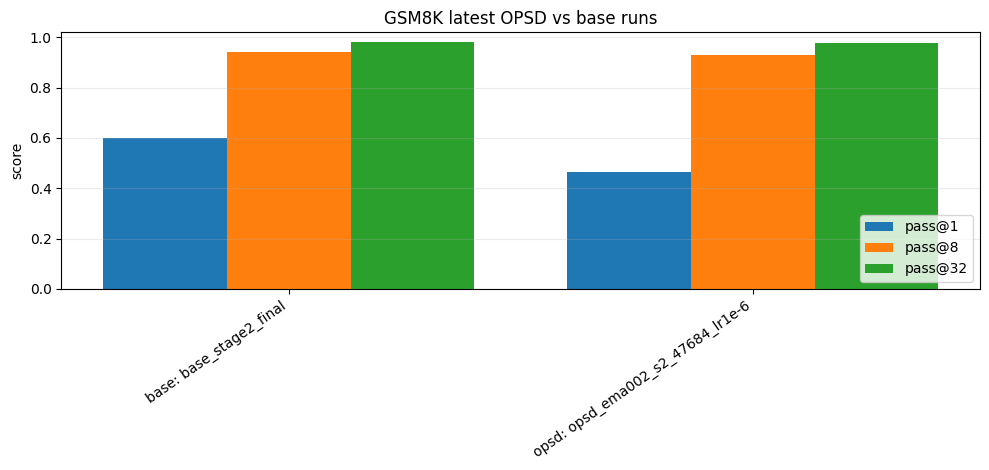

In [22]:
def plot_metric_bars(df: pd.DataFrame, metrics: list[str] = METRICS, title: str | None = None):
    if df.empty:
        print("No rows to plot.")
        return None

    plot_df = df.sort_values(["group", "checkpoint"]).copy()
    labels = plot_df["group"] + ": " + plot_df["checkpoint"]
    x = np.arange(len(plot_df))
    width = 0.8 / len(metrics)

    fig, ax = plt.subplots(figsize=(max(10, len(plot_df) * 1.4), 4.8))
    for i, metric in enumerate(metrics):
        ax.bar(x + (i - (len(metrics) - 1) / 2) * width, plot_df[metric], width, label=metric)

    ax.set_ylim(0, 1.02)
    ax.set_ylabel("score")
    ax.set_title(title or f"{TASK.upper()} latest OPSD vs base runs")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="lower right")
    fig.tight_layout()
    return fig


plot_metric_bars(latest_by_group_gsm);

,comparison,group,checkpoint,task,run_time,num_examples,max_new_tokens,pass@1,pass@8,pass@32,completion_tokens_mean,hit_max_new_tokens_rate,summary_path
0,stage2_base_vs_opsd,base,base_stage2_32000,gsm8k,2026-05-13 16:11:27,1319,512,0.6082,0.9372,0.9788,NaN,NaN,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
1,stage2_base_vs_opsd,base,base_stage2_47684,gsm8k,2026-05-13 16:19:30,1319,512,0.6021,0.9456,0.9818,NaN,NaN,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
2,stage2_base_vs_opsd,opsd,opsd_ema002_s2_32000_lr1e-6,gsm8k,2026-06-02 12:06:36,1319,7680,0.5676,0.9347,0.9826,231.9315,0.0082,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
3,stage2_base_vs_opsd,opsd,opsd_ema002_s2_47684_lr1e-6,gsm8k,2026-06-02 20:49:31,1319,7680,0.4653,0.9279,0.9765,252.4252,0.0140,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
4,stage2_base_vs_opsd,opsd,opsd_ema0_safe_s2_32000_lr1e-6,gsm8k,2026-06-01 22:24:54,1319,7680,0.4951,0.9286,0.9795,239.0846,0.0095,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
5,stage2_base_vs_opsd,opsd,opsd_ema0_safe_s2_47684_lr1e-6,gsm8k,2026-06-02 03:58:24,1319,7680,0.4579,0.9245,0.9727,258.7384,0.0150,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
6,stage2_step_32k_vs_47k,base,base_stage2_32000,gsm8k,2026-05-13 16:11:27,1319,512,0.6082,0.9372,0.9788,NaN,NaN,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
7,stage2_step_32k_vs_47k,base,base_stage2_47684,gsm8k,2026-05-13 16:19:30,1319,512,0.6021,0.9456,0.9818,NaN,NaN,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
8,stage2_step_32k_vs_47k,opsd,opsd_ema002_s2_32000_lr1e-6,gsm8k,2026-06-02 12:06:36,1319,7680,0.5676,0.9347,0.9826,231.9315,0.0082,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
9,stage2_step_32k_vs_47k,opsd,opsd_ema002_s2_47684_lr1e-6,gsm8k,2026-06-02 20:49:31,1319,7680,0.4653,0.9279,0.9765,252.4252,0.0140,/mnt/dlabscratch1/samaier/projects/SDPO-safety...


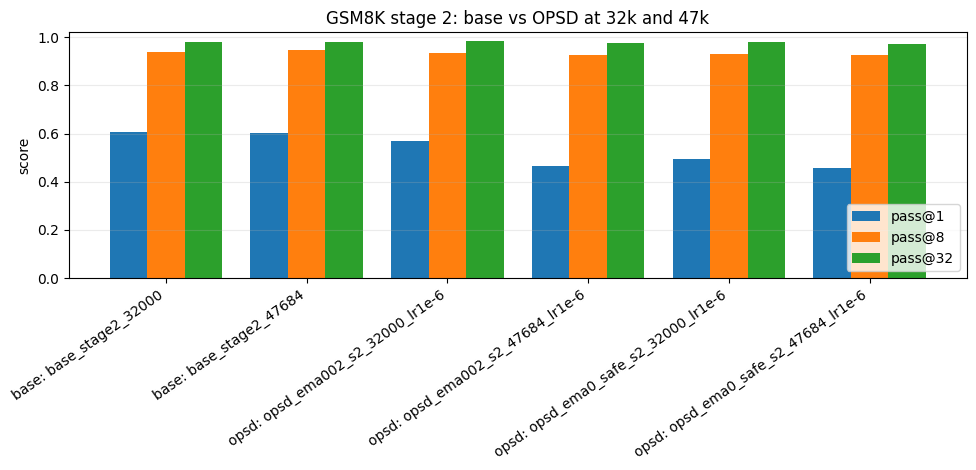

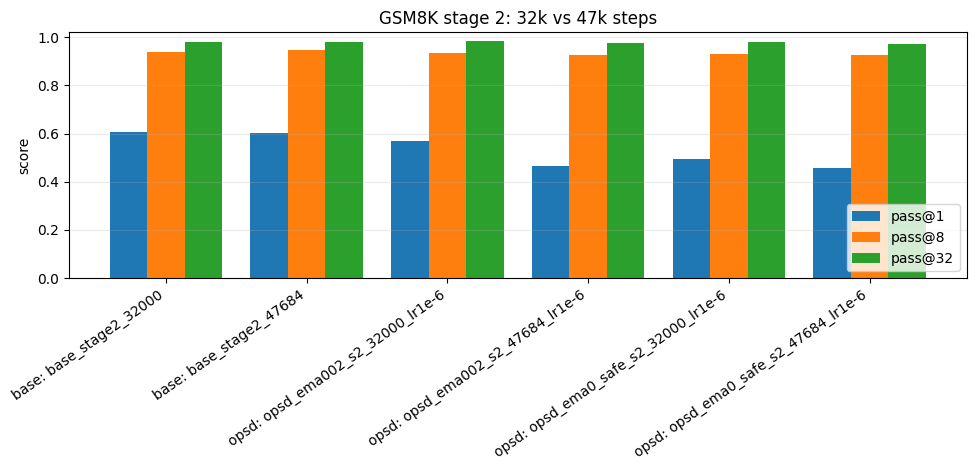

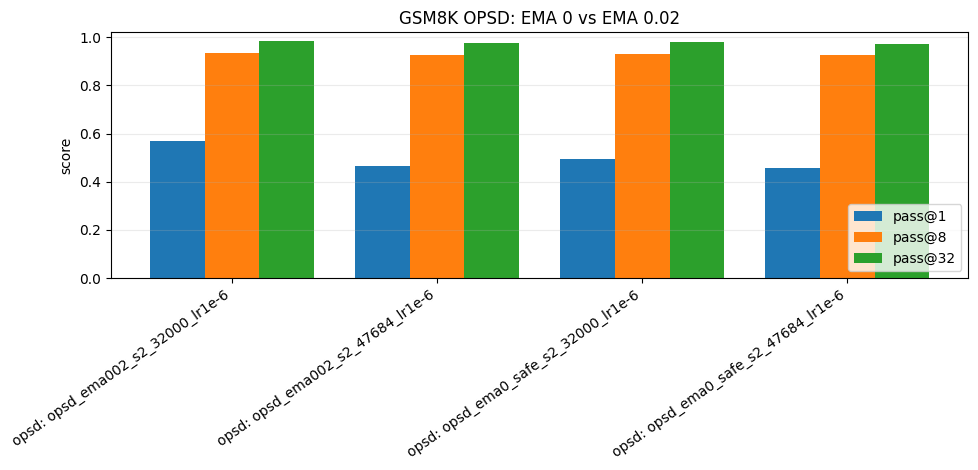

In [23]:
# Focused comparisons: base vs OPSD, step 32k vs 47k, EMA 0 vs 0.02.
# Uses latest_by_checkpoint_gsm from the summary collection cell above.

def comparison_slice(df: pd.DataFrame, checkpoint_patterns: list[str], label: str) -> pd.DataFrame:
    pattern = "|".join(checkpoint_patterns)
    out = df[df["checkpoint"].astype(str).str.contains(pattern, case=False, regex=True)].copy()
    out["comparison"] = label
    return out

stage2_base_vs_opsd = comparison_slice(
    latest_by_checkpoint_gsm,
    [
        r"base_stage2_32000$",
        r"base_stage2_47684$",
        r"opsd_ema0_safe_s2_32000_lr1e-6$",
        r"opsd_ema0_safe_s2_47684_lr1e-6$",
        r"opsd_ema002_s2_32000_lr1e-6$",
        r"opsd_ema002_s2_47684_lr1e-6$",
    ],
    "stage2_base_vs_opsd",
)

stage2_step_32k_vs_47k = comparison_slice(
    latest_by_checkpoint_gsm,
    [
        r"base_stage2_32000$",
        r"base_stage2_47684$",
        r"opsd_ema0_safe_s2_32000_lr1e-6$",
        r"opsd_ema0_safe_s2_47684_lr1e-6$",
        r"opsd_ema002_s2_32000_lr1e-6$",
        r"opsd_ema002_s2_47684_lr1e-6$",
    ],
    "stage2_step_32k_vs_47k",
)

opsd_ema0_vs_ema002 = comparison_slice(
    latest_by_checkpoint_gsm,
    [
        r"opsd_ema0_safe_s2_32000_lr1e-6$",
        r"opsd_ema002_s2_32000_lr1e-6$",
        r"opsd_ema0_safe_s2_47684_lr1e-6$",
        r"opsd_ema002_s2_47684_lr1e-6$",
    ],
    "opsd_ema0_vs_ema002",
)

focused_comparisons = pd.concat(
    [stage2_base_vs_opsd, stage2_step_32k_vs_47k, opsd_ema0_vs_ema002],
    ignore_index=True,
)

display_cols = [
    "comparison", "group", "checkpoint", "task", "run_time",
    "num_examples", "max_new_tokens", "pass@1", "pass@8", "pass@32",
    "completion_tokens_mean", "hit_max_new_tokens_rate", "summary_path",
]
display(focused_comparisons[[c for c in display_cols if c in focused_comparisons.columns]].round(4))

plot_metric_bars(stage2_base_vs_opsd, title="GSM8K stage 2: base vs OPSD at 32k and 47k");
plot_metric_bars(stage2_step_32k_vs_47k, title="GSM8K stage 2: 32k vs 47k steps");
plot_metric_bars(opsd_ema0_vs_ema002, title="GSM8K OPSD: EMA 0 vs EMA 0.02");


,stage2_step,model_family,checkpoint,pass@1_vs_matching_base,pass@8_vs_matching_base,pass@32_vs_matching_base
8,32000,base,base_stage2_32000,0.0000,0.0000,0.0000
9,47684,base,base_stage2_47684,0.0000,0.0000,0.0000
16,32000,opsd_ema002,opsd_ema002_s2_32000_lr1e-6,-0.0406,-0.0025,0.0038
18,47684,opsd_ema002,opsd_ema002_s2_47684_lr1e-6,-0.1369,-0.0177,-0.0053
20,32000,opsd_ema0,opsd_ema0_safe_s2_32000_lr1e-6,-0.1131,-0.0086,0.0008
22,47684,opsd_ema0,opsd_ema0_safe_s2_47684_lr1e-6,-0.1443,-0.0212,-0.0091


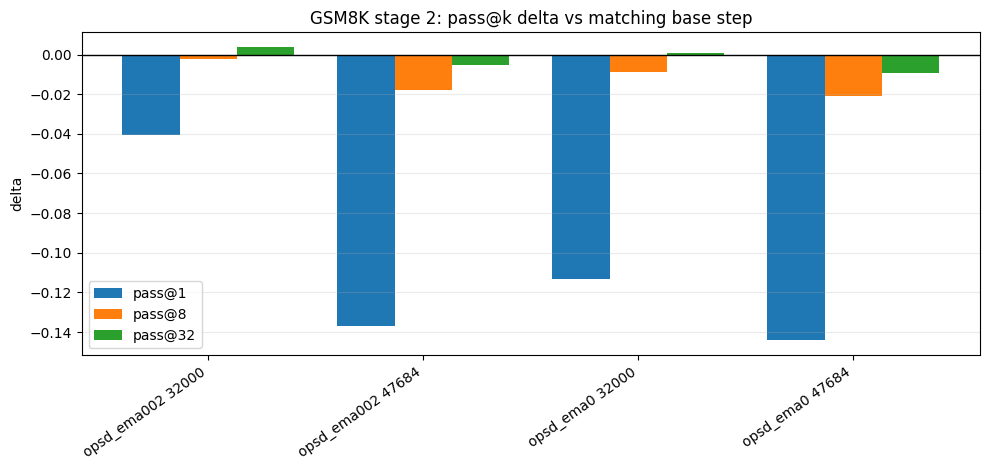

In [24]:
# Delta plots: pass@k difference versus the matching base checkpoint.

def add_step_and_family(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    checkpoint = out["checkpoint"].astype(str)
    out["stage2_step"] = np.select(
        [checkpoint.str.contains("32000"), checkpoint.str.contains("47684")],
        ["32000", "47684"],
        default="other",
    )
    out["model_family"] = np.select(
        [
            checkpoint.str.startswith("base_stage2"),
            checkpoint.str.contains("ema0_safe"),
            checkpoint.str.contains("ema002"),
        ],
        ["base", "opsd_ema0", "opsd_ema002"],
        default=out["group"].astype(str),
    )
    return out


def add_matching_base_deltas(df: pd.DataFrame, step_col: str = "stage2_step") -> pd.DataFrame:
    out = add_step_and_family(df)
    base = out[out["model_family"].eq("base")].set_index(step_col)

    for metric in METRICS:
        out[f"{metric}_vs_matching_base"] = out.apply(
            lambda row: row[metric] - base.loc[row[step_col], metric]
            if row[step_col] in base.index and metric in base.columns
            else np.nan,
            axis=1,
        )
    return out


def plot_pass_delta_bars(
    df: pd.DataFrame,
    delta_suffix: str = "_vs_matching_base",
    title: str = "pass@k delta vs matching base",
):
    delta_cols = [f"{metric}{delta_suffix}" for metric in METRICS]
    missing = [col for col in delta_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing delta columns: {missing}")

    plot_df = df.copy()
    plot_df = plot_df[plot_df[delta_cols].notna().any(axis=1)].copy()
    if plot_df.empty:
        print("No delta rows to plot.")
        return None

    label_parts = []
    for _, row in plot_df.iterrows():
        step = f" {row['stage2_step']}" if "stage2_step" in plot_df.columns else ""
        label_parts.append(f"{row['model_family']}{step}" if "model_family" in plot_df.columns else row["checkpoint"])

    x = np.arange(len(plot_df))
    width = 0.8 / len(delta_cols)

    fig, ax = plt.subplots(figsize=(max(10, len(plot_df) * 1.3), 4.8))
    for i, (metric, col) in enumerate(zip(METRICS, delta_cols)):
        ax.bar(x + (i - (len(delta_cols) - 1) / 2) * width, plot_df[col], width, label=metric)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_ylabel("delta")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(label_parts, rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig


stage2_base_vs_opsd_delta = add_matching_base_deltas(stage2_base_vs_opsd)
display_cols = [
    "stage2_step", "model_family", "checkpoint",
    "pass@1_vs_matching_base", "pass@8_vs_matching_base", "pass@32_vs_matching_base",
]
display(stage2_base_vs_opsd_delta[display_cols].round(4))

plot_pass_delta_bars(
    stage2_base_vs_opsd_delta[~stage2_base_vs_opsd_delta["model_family"].eq("base")],
    title="GSM8K stage 2: pass@k delta vs matching base step",
);


,stage2_step,model_family,checkpoint,completion_tokens_mean,completion_tokens_median,completion_tokens_p90,completion_tokens_p99,hit_max_new_tokens_rate,token_stats_available
8,32000,base,base_stage2_32000,NaN,NaN,NaN,NaN,NaN,False
9,47684,base,base_stage2_47684,NaN,NaN,NaN,NaN,NaN,False
16,32000,opsd_ema002,opsd_ema002_s2_32000_lr1e-6,231.93,147.0,283.0,2349.0,0.01,True
18,47684,opsd_ema002,opsd_ema002_s2_47684_lr1e-6,252.43,128.0,274.0,7680.0,0.01,True
20,32000,opsd_ema0,opsd_ema0_safe_s2_32000_lr1e-6,239.08,147.0,300.0,5768.0,0.01,True
22,47684,opsd_ema0,opsd_ema0_safe_s2_47684_lr1e-6,258.74,131.0,281.0,7680.0,0.02,True


Token stats are missing for these runs because their summary/prediction files do not store completion_tokens:


,checkpoint,summary_path
8,base_stage2_32000,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
9,base_stage2_47684,/mnt/dlabscratch1/samaier/projects/SDPO-safety...


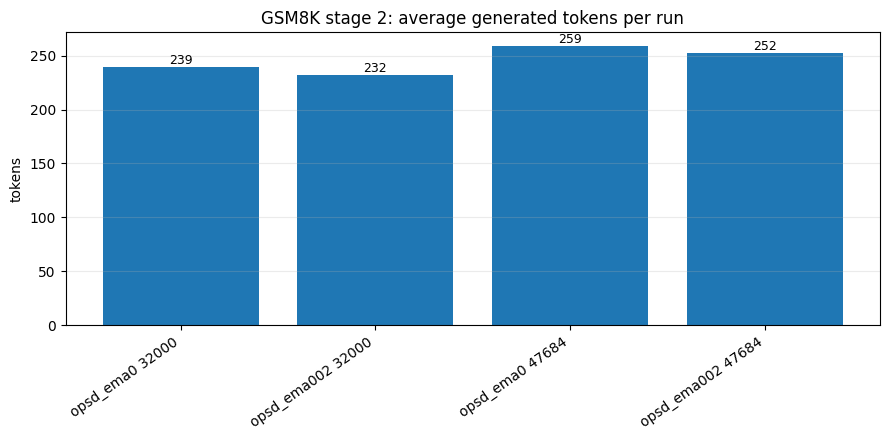

In [25]:
# Average generated tokens per run.

def plot_avg_tokens(
    df: pd.DataFrame,
    token_col: str = "completion_tokens_mean",
    title: str = "Average generated tokens per run",
):
    if token_col not in df.columns:
        raise ValueError(f"Missing token column: {token_col}")

    plot_df = df[df[token_col].notna()].copy()
    if plot_df.empty:
        print(f"No non-null values for {token_col}.")
        return None

    if "stage2_step" not in plot_df.columns or "model_family" not in plot_df.columns:
        plot_df = add_step_and_family(plot_df)

    plot_df = plot_df.sort_values(["stage2_step", "model_family", "checkpoint"])
    labels = plot_df["model_family"] + " " + plot_df["stage2_step"]

    fig, ax = plt.subplots(figsize=(max(9, len(plot_df) * 1.2), 4.5))
    ax.bar(np.arange(len(plot_df)), plot_df[token_col])
    ax.set_ylabel("tokens")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(plot_df)))
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(axis="y", alpha=0.25)

    for i, value in enumerate(plot_df[token_col]):
        ax.text(i, value, f"{value:.0f}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    return fig


token_display_cols = [
    "stage2_step", "model_family", "checkpoint",
    "completion_tokens_mean", "completion_tokens_median",
    "completion_tokens_p90", "completion_tokens_p99",
    "hit_max_new_tokens_rate", "token_stats_available",
]
stage2_token_summary = add_step_and_family(stage2_base_vs_opsd)
stage2_token_summary["token_stats_available"] = stage2_token_summary["completion_tokens_mean"].notna()
display(stage2_token_summary[[c for c in token_display_cols if c in stage2_token_summary.columns]].round(2))
missing_token_stats = stage2_token_summary[~stage2_token_summary["token_stats_available"]]
if not missing_token_stats.empty:
    print("Token stats are missing for these runs because their summary/prediction files do not store completion_tokens:")
    display(missing_token_stats[["checkpoint", "summary_path"]])

plot_avg_tokens(
    stage2_token_summary,
    token_col="completion_tokens_mean",
    title="GSM8K stage 2: average generated tokens per run",
);


In [26]:
# Optional: inspect the raw runs that fed the latest table.
raw_cols = ["group", "checkpoint", "task", "root", "run_time", "pass@1", "pass@8", "pass@32", "summary_path"]
display(all_gsm[[c for c in raw_cols if c in all_gsm.columns]].sort_values("run_time", ascending=False).head(30).round(4))

,group,checkpoint,task,root,run_time,pass@1,pass@8,pass@32,summary_path
24,opsd,opsd_ema002_s2_47684_lr1e-6,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680,2026-06-02 20:49:31,0.4653,0.9279,0.9765,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
23,opsd,opsd_ema002_s2_32000_lr5e-6,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680,2026-06-02 17:42:29,0.5734,0.9376,0.9833,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
22,opsd,opsd_ema002_s2_32000_lr1e-6,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680,2026-06-02 12:06:36,0.5676,0.9347,0.9826,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
21,opsd,opsd_ema0_safe_s2_47684_lr5e-6,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680,2026-06-02 08:05:42,0.4320,0.9309,0.9810,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
20,opsd,opsd_ema0_safe_s2_47684_lr1e-6,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680,2026-06-02 03:58:24,0.4579,0.9245,0.9727,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
19,opsd,opsd_ema0_safe_s2_32000_lr5e-6,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680,2026-06-02 01:33:12,0.5244,0.9281,0.9765,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
18,opsd,opsd_ema0_safe_s2_32000_lr1e-6,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680,2026-06-01 22:24:54,0.4951,0.9286,0.9795,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
17,opsd,opsd_ema002_s2_47684_lr1e-6_latest,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680_latest2,2026-06-01 12:49:33,0.4152,0.9202,0.9765,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
16,opsd,opsd_ema0_safe_s2_47684_lr1e-6_latest,gsm8k,longctx_opsd_stage2_gsm8k_maxnew7680_latest2,2026-06-01 08:42:02,0.4486,0.9294,0.9795,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
15,base,base_stage2_final,gsm8k,base_stage12_len8k_gsm8k_math_500,2026-05-27 06:00:00,0.5979,0.9436,0.9820,/mnt/dlabscratch1/samaier/projects/SDPO-safety...
